# Code to reproduce the statistics reported in Table 2 of the report

In [73]:
import pandas as pd
import numpy as np
from scipy import stats

(forgive the horrible column naming, its from an Excel workbook)

In [74]:
T_RES_COLS = ['Res 1', 'Res 2', 'Res 3 ', 'Res 4', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10']
S_RES_COLS = ['Res 1', 'Res 2', 'Res 3', 'Res 4', 'Res 5', 'Res 6', 'Res 7', 'Res 8','Res 9', 'Res 10', 'Res 11', 'Res 12', 'Res 13', 'Res 14', 'Res 15', 'Res 16', 'Res 17', 'Res 18', 'Res 19', 'Res 20', 'Res 21']

transect = pd.read_csv('../../../datastore/Transect.csv') # transect dataframe
ssdf = pd.read_csv('../../../datastore/SCDs.csv') # somerset scds dataframe

# transect data
t_data = transect[T_RES_COLS].copy()
t_data['SCD'] = False

# scd data
s_data = ssdf[S_RES_COLS].copy()
s_data['SCD'] = True

# total df
df = pd.concat([t_data, s_data], axis=0)

# only actual concentration measurements
measurement_cols = [c for c in df.columns if c != 'SCD']
measurements = df[measurement_cols].apply(pd.to_numeric, errors='coerce')

df['mean'] = measurements.mean(axis=1)
df['median'] = measurements.median(axis=1)
df['max'] = measurements.max(axis=1)

s_data['mean'] = s_data[S_RES_COLS].apply(pd.to_numeric, errors='coerce').mean(axis=1)
t_data['mean'] = t_data[T_RES_COLS].apply(pd.to_numeric, errors='coerce').mean(axis=1)


In [75]:
def get_mad(df):
    return (df['mean'] - df['mean'].median()).abs().median()

def background(df):
    mad = get_mad(df)
    median = df['mean'].median()
    background_level = median + 2 * mad
    return background_level

In [76]:
def get_concentration_stats(df):
    transect_mean = df[df['SCD'] == False]['mean'].mean()
    scd_mean = df[df['SCD'] == True]['mean'].mean()

    transect_median = df[df['SCD'] == False]['mean'].median()
    scd_median = df[df['SCD'] == True]['mean'].median()

    transect_mad = get_mad(df[df['SCD'] == False])
    scd_mad = get_mad(df[df['SCD'] == True])

    return {
        'transect_mean': transect_mean,
        'scd_mean': scd_mean,
        'transect_median': transect_median,
        'scd_median': scd_median,
        'transect_mad': transect_mad,
        'scd_mad': scd_mad
    }

In [77]:
print(f'Dataset Stats: \nSCD Mean: {get_concentration_stats(df)["scd_mean"]:.3f} \
    \nTransect Mean: {get_concentration_stats(df)["transect_mean"]:.3f} \nSCD Median: {get_concentration_stats(df)["scd_median"]:.3f} \n\
Transect Median: {get_concentration_stats(df)["transect_median"]:.3f} \nSCD MAD: {get_concentration_stats(df)["scd_mad"]:.3f} \n\
Transect MAD: {get_concentration_stats(df)["transect_mad"]:.3f}')

Dataset Stats: 
SCD Mean: 12.037     
Transect Mean: 11.147 
SCD Median: 9.308 
Transect Median: 4.750 
SCD MAD: 5.708 
Transect MAD: 2.000


In [78]:
df = df[df['mean'] < 100]

mad = get_mad(df)
median = df['mean'].median()
background_level = median + 2 * mad

print(f'Background level: {background_level:.3f}')


Background level: 11.850


Number of points above background level

In [79]:
print(f'number of points above background: {len(df[df["mean"] > background(df)])}')

number of points above background: 9


Concentrations above 40 ppm

In [80]:
print(f'Number of sites with maximum concentration above 40 ppm: {len(df[df["max"] >= 40])}')

Number of sites with maximum concentration above 40 ppm: 8


In [81]:
print(f'SCDs above background: {len(df[(df["SCD"] == True) & (df["mean"] > background(df))])}')

SCDs above background: 5


In [82]:
print(f'Means of maximum concentrations at SCD sites: {df[df["SCD"] == True]["max"].mean():.3f}')
print(f'Means of maximum concentrations at non-SCD sites: {df[df["SCD"] == False]["max"].mean():.3f}')

Means of maximum concentrations at SCD sites: 30.267
Means of maximum concentrations at non-SCD sites: 13.333


Mann Whitney population analysis

In [83]:
non_SCDs

,Res 1,Res 2,Res 3,Res 4,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,SCD,Res 3,...,Res 15,Res 16,Res 17,Res 18,Res 19,Res 20,Res 21,mean,median,max
0,3,3,3.0,3,NaN,NaN,NaN,NaN,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.00,3.0,3.0
1,5,46,41.0,22,NaN,NaN,NaN,NaN,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.50,31.5,46.0
2,2,2,1.0,40,NaN,NaN,NaN,NaN,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.25,2.0,40.0
3,4,5,13.0,9,NaN,NaN,NaN,NaN,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.75,7.0,13.0
4,1,3,1.0,2,NaN,NaN,NaN,NaN,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.75,1.5,3.0
5,3,3,3.0,0,NaN,NaN,NaN,NaN,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.25,3.0,3.0
6,1,3,2.0,13,NaN,NaN,NaN,NaN,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.75,2.5,13.0
7,3,3,2.0,7,NaN,NaN,NaN,NaN,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.75,3.0,7.0
8,4,5,2.0,1,NaN,NaN,NaN,NaN,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.00,3.0,5.0
9,0,2,1.0,6,NaN,NaN,NaN,NaN,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.25,1.5,6.0


In [84]:
SCDs = df[df['SCD']]
non_SCDs = df[~df['SCD']]

# for one mw test, only include non-SCDs with mean < 100
# other tests are also included!

def get_mannwhitneyu(SCDs, non_SCDs, field='median'):
    return stats.mannwhitneyu(
        SCDs[field].dropna(),
        non_SCDs[field].dropna(),
        alternative='two-sided'
    )

for field in ['max', 'median', 'mean']:
    u, p = get_mannwhitneyu(SCDs, non_SCDs, field)
    print(f'{field}: U={u:.3f}, p={p:.6f}')

max: U=343.000, p=0.034232
median: U=297.000, p=0.274281
mean: U=303.000, p=0.220970


In [85]:
print(f'Median of peak concentrations at SCDs: {SCDs["max"].median():.3f}')

Median of peak concentrations at SCDs: 23.000


In [86]:
all_scd_vals = ssdf[S_RES_COLS].stack().dropna()

# change 200ppm to 300ppm (from gas analysis)
transect[transect == 200] = 300
all_transect_vals = transect[T_RES_COLS].stack().dropna()

all_vals = pd.concat([all_scd_vals, all_transect_vals], axis=0)

In [87]:
print(f'Stats of SCD population: count={len(all_scd_vals)}, max={all_scd_vals.max():.3f}, mean={all_scd_vals.mean():.3f}, median={all_scd_vals.median():.3f}, std={all_scd_vals.std():.3f}')
print(f'Stats of non-SCD population: count={len(all_transect_vals)}, max={all_transect_vals.max():.3f}, mean={all_transect_vals.mean():.3f}, median={all_transect_vals.median():.3f}, std={all_transect_vals.std():.3f}')
print(f'stats of whole population: count={len(all_vals)}, max={all_vals.max():.3f}, mean={all_vals.mean():.3f}, median={all_vals.median():.3f}, std={all_vals.std():.3f}')

Stats of SCD population: count=127, max=106.000, mean=16.972, median=10.000, std=19.177
Stats of non-SCD population: count=142, max=300.000, mean=13.711, median=5.000, std=34.481
stats of whole population: count=269, max=300.000, mean=15.251, median=5.000, std=28.304


Text(0.5, 1.0, 'Histogram of Mean Concentrations for SCD and non-SCD Populations')

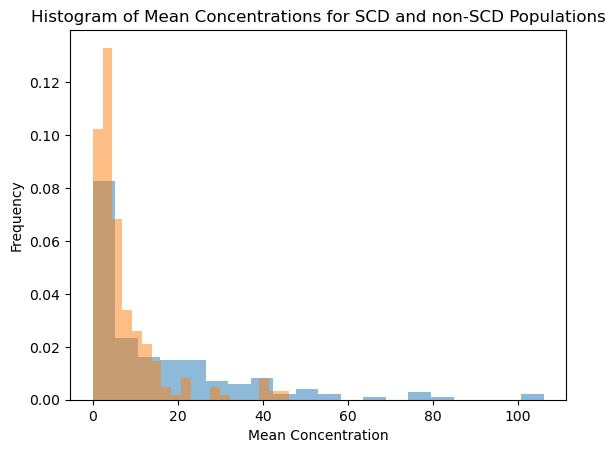

In [88]:
# plot hist of scd and non scd populations
import matplotlib.pyplot as plt

# normalise to number of samples

plt.hist(SCDs.stack(), density=True, bins=20, alpha=0.5, label='SCDs')
plt.hist(non_SCDs.stack(), density=True, bins=20, alpha=0.5, label='non-SCDs')
plt.xlabel('Mean Concentration')
plt.ylabel('Frequency')
plt.title('Histogram of Mean Concentrations for SCD and non-SCD Populations')       

In [89]:
# averages of each population

print(f'stats of SCD population averaged at locality level: count={len(s_data)}, max={s_data["mean"].max():.3f}, mean={s_data["mean"].mean():.3f}, median={s_data["mean"].median():.3f}, 25th percentile={s_data["mean"].quantile(0.25):.3f}, 75th percentile={s_data["mean"].quantile(0.75):.3f}')
print(f'stats of non-SCD population averaged at locality level: count={len(t_data)}, max={t_data["mean"].max():.3f}, mean={t_data["mean"].mean():.3f}, median={t_data["mean"].median():.3f}, 25th percentile={t_data["mean"].quantile(0.25):.3f}, 75th percentile={t_data["mean"].quantile(0.75):.3f}')

stats of SCD population averaged at locality level: count=15, max=36.357, mean=12.037, median=9.308, 25th percentile=3.675, 75th percentile=16.783
stats of non-SCD population averaged at locality level: count=34, max=142.500, mean=11.147, median=4.750, 25th percentile=3.500, 75th percentile=8.812


In [90]:
print(f'mean of maximum concentrations at non-SCD sites: {df[df["SCD"] == False]["max"].mean():.3f}')
print(f'mean of maximum concentrations at SCD sites: {df[df["SCD"] == True]["max"].mean():.3f}')

mean of maximum concentrations at non-SCD sites: 13.333
mean of maximum concentrations at SCD sites: 30.267
